# **Enhancing Phishing Detection: A Machine Learning Approach With Feature Selection and Deep Learning Models**

# * Import Necessary Libraries.*

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Load Dataset

In [2]:
df =pd.read_csv('/kaggle/input/datasetphishing/dataset_B_05_2020 (1).csv')

In [3]:
if 'url' in df.columns:
    df.drop('url', axis=1, inplace=True)

In [4]:
# Step 12: Class Imbalance (if any)
class_counts = df['status'].value_counts()
print("\nClass Distribution:")
print(class_counts)
print("\nClass Ratio: {:.2f}% Legit / {:.2f}% Phishing".format(
    100 * class_counts[0] / len(df), 100 * class_counts[1] / len(df)))


Class Distribution:
status
legitimate    5715
phishing      5715
Name: count, dtype: int64

Class Ratio: 50.00% Legit / 50.00% Phishing


/tmp/ipykernel_47/309273247.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  100 * class_counts[0] / len(df), 100 * class_counts[1] / len(df)))


### Convert 'status' to numeric binary values

In [5]:
# Convert 'status' to numeric binary values
df['status'] = df['status'].map({'legitimate': 0, 'phishing': 1})

In [6]:
from sklearn.impute import SimpleImputer
numeric_imputer = SimpleImputer(strategy='median')
df_imputed = pd.DataFrame(numeric_imputer.fit_transform(df), columns=df.columns)

# Assuming df_imputed is your dataset and 'status' is your target column and Feature Selection using SelectKBest

In [7]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd

# Assuming df_imputed is your dataset and 'status' is your target column
X = df_imputed.drop('status', axis=1)  # Features
y = df_imputed['status']  # Target

# Step 1: Feature Selection using SelectKBest
k = 20  # Select top 20 features (change this value as needed)
selector = SelectKBest(score_func=f_classif, k=k)
X_kbest = selector.fit_transform(X, y)

# Step 2: Get the selected feature names
selected_feature_names = X.columns[selector.get_support()]

# Step 3: Scale only the selected features using StandardScaler
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X[selected_feature_names]), columns=selected_feature_names)

# Step 4: Train-Test Split with the selected and scaled features
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Display the top k selected feature names after scaling
print("Top", k, "features selected and scaled:")
print(selected_feature_names.tolist())

# You can now train and evaluate your models using X_train and X_test


Top 20 features selected and scaled:
['length_url', 'length_hostname', 'ip', 'nb_qm', 'nb_eq', 'nb_slash', 'nb_www', 'ratio_digits_url', 'ratio_digits_host', 'tld_in_subdomain', 'prefix_suffix', 'shortest_word_host', 'longest_word_path', 'phish_hints', 'nb_hyperlinks', 'ratio_intHyperlinks', 'domain_in_title', 'domain_age', 'google_index', 'page_rank']


/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [ 8 59 61 63 68 71] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [8]:
X_train.columns

Index(['length_url', 'length_hostname', 'ip', 'nb_qm', 'nb_eq', 'nb_slash',
       'nb_www', 'ratio_digits_url', 'ratio_digits_host', 'tld_in_subdomain',
       'prefix_suffix', 'shortest_word_host', 'longest_word_path',
       'phish_hints', 'nb_hyperlinks', 'ratio_intHyperlinks',
       'domain_in_title', 'domain_age', 'google_index', 'page_rank'],
      dtype='object')

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_curve, roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# ======= Data to Tensors =======
X_train_tensor = torch.FloatTensor(X_train.values)
X_test_tensor = torch.FloatTensor(X_test.values)
y_train_tensor = torch.LongTensor(y_train.values)
y_test_tensor = torch.LongTensor(y_test.values)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=64)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [19]:
!pip install torch scikit-learn pandas matplotlib seaborn tab-transformer-pytorch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.8/899.8 MB 2.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 2.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 123.4 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 2.7 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 1.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 2.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 9.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 30.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 4.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 MB 6.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━

In [20]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from torch.utils.data import TensorDataset, DataLoader
from tab_transformer_pytorch import TabTransformer
import matplotlib.pyplot as plt
import warnings

In [30]:
# Separate features and target
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
X = df_imputed.drop('status', axis=1)
y = df_imputed['status']

# Feature Scaling
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Select Top-K Features
k = 20  # You can change this to any number of top features you want
selector = SelectKBest(score_func=f_classif, k=k)
X_kbest = selector.fit_transform(X_scaled, y)

# Get the names of the selected features
selected_feature_names = X.columns[selector.get_support()]
print("Top", k, "features selected:")
print(selected_feature_names.tolist())

#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_kbest, y, test_size=0.2, random_state=42, stratify=y)

Top 20 features selected:
['length_url', 'length_hostname', 'ip', 'nb_qm', 'nb_eq', 'nb_slash', 'nb_www', 'ratio_digits_url', 'ratio_digits_host', 'tld_in_subdomain', 'prefix_suffix', 'shortest_word_host', 'longest_word_path', 'phish_hints', 'nb_hyperlinks', 'ratio_intHyperlinks', 'domain_in_title', 'domain_age', 'google_index', 'page_rank']


/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [ 8 59 61 63 68 71] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


### **Model Training*

In [44]:
# =================== TABTRANSFORMER MODEL ===================
class TabTransformer(nn.Module):
    def __init__(self, num_continuous, dim=64, depth=4, heads=8, attn_dropout=0.1, ff_dropout=0.2, mlp_hidden_mults=(4, 2)):
        super(TabTransformer, self).__init__()
        
        self.num_continuous = num_continuous
        self.dim = dim
        
        # Continuous features projection
        self.continuous_proj = nn.Linear(num_continuous, dim)
        
        # Transformer encoder (batch_first=True for cleaner handling)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=dim, 
            nhead=heads, 
            dim_feedforward=dim * 4, 
            dropout=attn_dropout,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        
        # MLP Head
        mlp_layers = []
        mlp_layers.extend([
            nn.Linear(dim, dim * mlp_hidden_mults[0]),
            nn.ReLU(),
            nn.Dropout(ff_dropout),
            nn.Linear(dim * mlp_hidden_mults[0], dim * mlp_hidden_mults[1]),
            nn.ReLU(),
            nn.Dropout(ff_dropout),
            nn.Linear(dim * mlp_hidden_mults[1], 2)  # Binary classification
        ])
        self.mlp_head = nn.Sequential(*mlp_layers)
    
    def forward(self, x_cont):
        batch_size = x_cont.size(0)
        
        # Project continuous features
        x = self.continuous_proj(x_cont)  # [batch, dim]
        
        # Add sequence dimension for transformer (treat each sample as seq_len=1)
        x = x.unsqueeze(1)  # [batch, 1, dim]
        
        # Transformer encoding
        x = self.encoder(x)  # [batch, 1, dim]
        x = x.squeeze(1)     # [batch, dim] - remove sequence dimension
        
        # Classification head
        out = self.mlp_head(x)
        return out

# =================== TRAINING FUNCTION ===================
def train_tab_transformer(input_dim, train_loader, test_loader, epochs=50, lr=0.001):
    # Model initialization
    model = TabTransformer(
        num_continuous=input_dim,
        dim=64,
        depth=4,
        heads=8,
        attn_dropout=0.1,
        ff_dropout=0.2,
        mlp_hidden_mults=(4, 2)
    ).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    loss_fn = nn.CrossEntropyLoss()
    
    # Training loop
    best_auc = 0
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            
            optimizer.zero_grad()
            out = model(xb)
            loss = loss_fn(out, yb)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item()
        
        # Validation
        model.eval()
        val_auc = evaluate_model(model, test_loader)
        
        scheduler.step(train_loss / len(train_loader))
        
        if val_auc > best_auc:
            best_auc = val_auc
        
        print(f"Epoch {epoch+1}/{epochs} | Loss: {train_loss/len(train_loader):.4f} | Val AUC: {val_auc:.4f} | Best AUC: {best_auc:.4f}")
    
    return evaluate_model(model, test_loader, full_metrics=True)

def evaluate_model(model, test_loader, full_metrics=False):
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            prob = torch.softmax(out, dim=1)[:, 1]
            pred = torch.argmax(out, dim=1)
            
            y_true.extend(yb.cpu().numpy())
            y_pred.extend(pred.cpu().numpy())
            y_prob.extend(prob.cpu().numpy())
    
    if full_metrics:
        return {
            'Accuracy': accuracy_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred, zero_division=0),
            'Recall': recall_score(y_true, y_pred, zero_division=0),
            'F1 Score': f1_score(y_true, y_pred, zero_division=0),
            'AUC': roc_auc_score(y_true, y_prob)
        }
    else:
        return roc_auc_score(y_true, y_prob)

# =================== EXECUTION ===================
# Convert to tensors and create data loaders
X_train_tensor = torch.FloatTensor(X_train)
X_test_tensor = torch.FloatTensor(X_test)
y_train_tensor = torch.LongTensor(y_train.values)
y_test_tensor = torch.LongTensor(y_test.values)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=64, shuffle=False)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("🖥 Using device:", device)
print(f"📊 Training samples: {len(train_loader.dataset)}, Test samples: {len(test_loader.dataset)}")
print(f"✨ Input features: {X_train.shape[1]}")

# Train the model
print("\n🚀 Starting TabTransformer training...")
tab_transformer_results = train_tab_transformer(
    input_dim=X_train_tensor.shape[1], 
    train_loader=train_loader, 
    test_loader=test_loader,
    epochs=50,
    lr=0.001
)

# Print final results
print("\n📊 TabTransformer Final Results:")
print("=" * 50)
for metric, value in tab_transformer_results.items():
    print(f"✅ {metric}: {value:.4f}")

print(f"\n🎉 Training completed successfully!")

🖥 Using device: cuda
📊 Training samples: 9144, Test samples: 2286
✨ Input features: 20

🚀 Starting TabTransformer training...
Epoch 1/50 | Loss: 0.2252 | Val AUC: 0.9812 | Best AUC: 0.9812
Epoch 2/50 | Loss: 0.1656 | Val AUC: 0.9835 | Best AUC: 0.9835
Epoch 3/50 | Loss: 0.1553 | Val AUC: 0.9829 | Best AUC: 0.9835
Epoch 4/50 | Loss: 0.1469 | Val AUC: 0.9862 | Best AUC: 0.9862
Epoch 5/50 | Loss: 0.1409 | Val AUC: 0.9839 | Best AUC: 0.9862
Epoch 6/50 | Loss: 0.1358 | Val AUC: 0.9841 | Best AUC: 0.9862
Epoch 7/50 | Loss: 0.1351 | Val AUC: 0.9857 | Best AUC: 0.9862
Epoch 8/50 | Loss: 0.1358 | Val AUC: 0.9870 | Best AUC: 0.9870
Epoch 9/50 | Loss: 0.1257 | Val AUC: 0.9851 | Best AUC: 0.9870
Epoch 10/50 | Loss: 0.1258 | Val AUC: 0.9841 | Best AUC: 0.9870
Epoch 11/50 | Loss: 0.1250 | Val AUC: 0.9851 | Best AUC: 0.9870
Epoch 12/50 | Loss: 0.1211 | Val AUC: 0.9851 | Best AUC: 0.9870
Epoch 13/50 | Loss: 0.1167 | Val AUC: 0.9866 | Best AUC: 0.9870
Epoch 14/50 | Loss: 0.1113 | Val AUC: 0.9864 | Best

/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [ 8 59 61 63 68 71] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Top 20 features selected:
['length_url', 'length_hostname', 'ip', 'nb_qm', 'nb_eq', 'nb_slash', 'nb_www', 'ratio_digits_url', 'ratio_digits_host', 'tld_in_subdomain', 'prefix_suffix', 'shortest_word_host', 'longest_word_path', 'phish_hints', 'nb_hyperlinks', 'ratio_intHyperlinks', 'domain_in_title', 'domain_age', 'google_index', 'page_rank']
🖥 Using device: cuda

🚀 Training TabTransformer...
Epoch 1/50 | Loss: 0.2166 | Val AUC: 0.9800
Epoch 2/50 | Loss: 0.1731 | Val AUC: 0.9843
Epoch 3/50 | Loss: 0.1599 | Val AUC: 0.9834
Epoch 4/50 | Loss: 0.1517 | Val AUC: 0.9858
Epoch 5/50 | Loss: 0.1450 | Val AUC: 0.9864
Epoch 6/50 | Loss: 0.1358 | Val AUC: 0.9860
Epoch 7/50 | Loss: 0.1383 | Val AUC: 0.9870
Epoch 8/50 | Loss: 0.1286 | Val AUC: 0.9871
Epoch 9/50 | Loss: 0.1280 | Val AUC: 0.9872
Epoch 10/50 | Loss: 0.1268 | Val AUC: 0.9864
Epoch 11/50 | Loss: 0.1182 | Val AUC: 0.9857
Epoch 12/50 | Loss: 0.1179 | Val AUC: 0.9844
Epoch 13/50 | Loss: 0.1196 | Val AUC: 0.9863
Epoch 14/50 | Loss: 0.1145 | 

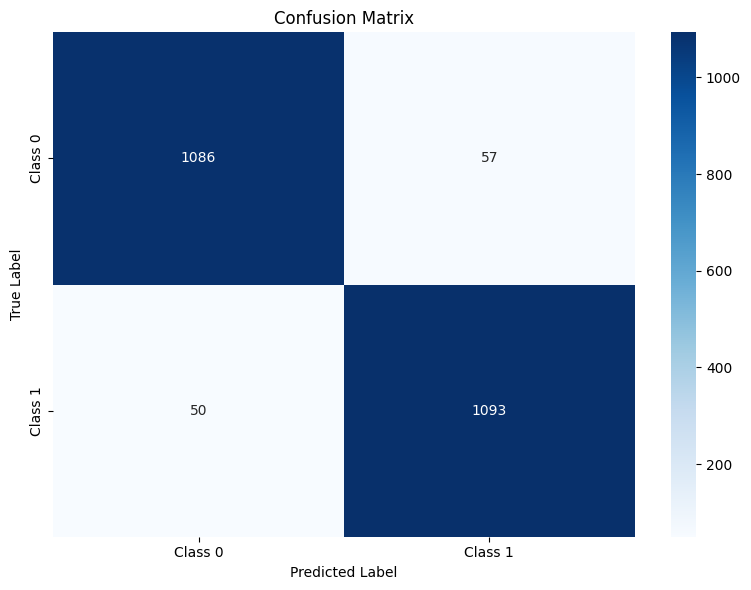


📊 Confusion Matrix Summary:
Total samples: 2286
Accuracy: 0.9532
True Positives: 1093 (47.8%)
False Positives: 57 (2.5%)
False Negatives: 50 (2.2%)
True Negatives: 1086 (47.5%)


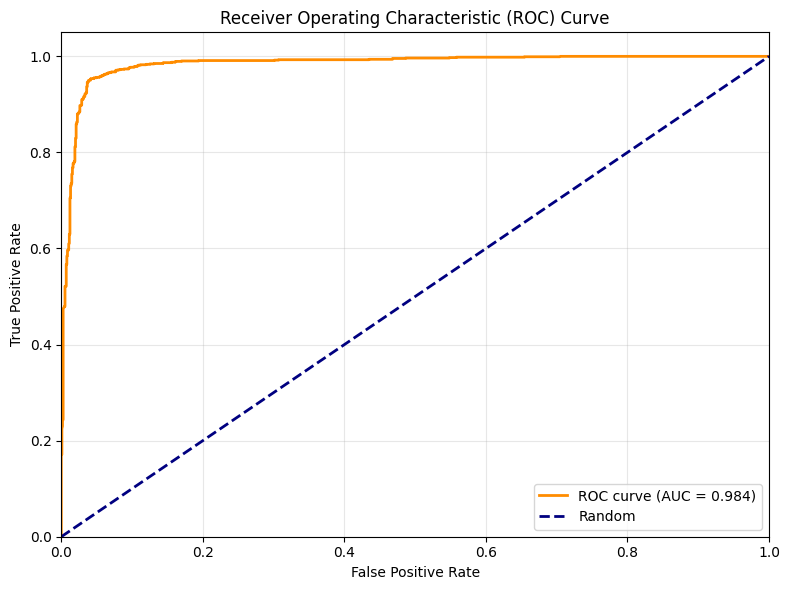


🎯 ROC AUC Score: 0.9839

📊 COMPLETE PERFORMANCE METRICS:
----------------------------------------
✅ Accuracy  : 0.9532
✅ Precision : 0.9504
✅ Recall    : 0.9563
✅ F1 Score  : 0.9533
✅ AUC       : 0.9839

🎉 Analysis complete! Model ready for deployment.


In [46]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# =================== DATA PREPROCESSING (Your existing code) ===================
X = df_imputed.drop('status', axis=1)
y = df_imputed['status']

# Feature Scaling
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Select Top-K Features
k = 20
selector = SelectKBest(score_func=f_classif, k=k)
X_kbest = selector.fit_transform(X_scaled, y)

selected_feature_names = X.columns[selector.get_support()]
print("Top", k, "features selected:")
print(selected_feature_names.tolist())

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_kbest, y, test_size=0.2, random_state=42, stratify=y
)

# =================== TABTRANSFORMER MODEL (Your existing model) ===================
class TabTransformer(nn.Module):
    def __init__(self, num_continuous, dim=64, depth=4, heads=8, attn_dropout=0.1, ff_dropout=0.2, mlp_hidden_mults=(4, 2)):
        super(TabTransformer, self).__init__()
        self.num_continuous = num_continuous
        self.dim = dim
        
        self.continuous_proj = nn.Linear(num_continuous, dim)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=dim, nhead=heads, dim_feedforward=dim * 4, 
            dropout=attn_dropout, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        
        mlp_layers = [
            nn.Linear(dim, dim * mlp_hidden_mults[0]),
            nn.ReLU(), nn.Dropout(ff_dropout),
            nn.Linear(dim * mlp_hidden_mults[0], dim * mlp_hidden_mults[1]),
            nn.ReLU(), nn.Dropout(ff_dropout),
            nn.Linear(dim * mlp_hidden_mults[1], 2)
        ]
        self.mlp_head = nn.Sequential(*mlp_layers)
    
    def forward(self, x_cont):
        x = self.continuous_proj(x_cont)
        x = x.unsqueeze(1)  # [batch, 1, dim]
        x = self.encoder(x)
        x = x.squeeze(1)    # [batch, dim]
        return self.mlp_head(x)

# =================== TRAINING FUNCTION (Your existing training) ===================
def train_tab_transformer(input_dim, train_loader, test_loader, epochs=50, lr=0.001):
    model = TabTransformer(num_continuous=input_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5)
    loss_fn = nn.CrossEntropyLoss()
    
    best_auc = 0
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = loss_fn(out, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item()
        
        val_auc = evaluate_model(model, test_loader)
        scheduler.step(train_loss / len(train_loader))
        
        if val_auc > best_auc:
            best_auc = val_auc
        
        print(f"Epoch {epoch+1}/{epochs} | Loss: {train_loss/len(train_loader):.4f} | Val AUC: {val_auc:.4f}")
    
    return model

def evaluate_model(model, test_loader):
    model.eval()
    y_true, y_prob = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            prob = torch.softmax(out, dim=1)[:, 1]
            y_true.extend(yb.cpu().numpy())
            y_prob.extend(prob.cpu().numpy())
    return roc_auc_score(y_true, y_prob)

# =================== NEW: CONFUSION MATRIX & ROC CURVE FUNCTIONS ===================
def plot_confusion_matrix(model, test_loader, class_names=['Class 0', 'Class 1']):
    """Generate and plot confusion matrix"""
    model.eval()
    y_true, y_pred = [], []
    
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            pred = torch.argmax(out, dim=1)
            y_true.extend(yb.cpu().numpy())
            y_pred.extend(pred.cpu().numpy())
    
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()
    
    # Print confusion matrix stats
    total = np.sum(cm)
    accuracy = np.trace(cm) / total
    print(f"\n📊 Confusion Matrix Summary:")
    print(f"Total samples: {total}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"True Positives: {cm[1,1]} ({cm[1,1]/total:.1%})")
    print(f"False Positives: {cm[0,1]} ({cm[0,1]/total:.1%})")
    print(f"False Negatives: {cm[1,0]} ({cm[1,0]/total:.1%})")
    print(f"True Negatives: {cm[0,0]} ({cm[0,0]/total:.1%})")
    
    return cm

def plot_roc_curve(model, test_loader):
    """Generate and plot ROC curve"""
    model.eval()
    y_true, y_prob = [], []
    
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            prob = torch.softmax(out, dim=1)[:, 1]
            y_true.extend(yb.cpu().numpy())
            y_prob.extend(prob.cpu().numpy())
    
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, 
             label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"\n🎯 ROC AUC Score: {roc_auc:.4f}")
    return roc_auc

# =================== EXECUTION ===================
# Create tensors and data loaders
X_train_tensor = torch.FloatTensor(X_train)
X_test_tensor = torch.FloatTensor(X_test)
y_train_tensor = torch.LongTensor(y_train.values)
y_test_tensor = torch.LongTensor(y_test.values)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=64, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("🖥 Using device:", device)

# Train model
print("\n🚀 Training TabTransformer...")
model = train_tab_transformer(
    input_dim=X_train_tensor.shape[1], 
    train_loader=train_loader, 
    test_loader=test_loader,
    epochs=50
)

# =================== GENERATE VISUALIZATIONS ===================
print("\n" + "="*60)
print("📈 GENERATING CONFUSION MATRIX & ROC CURVE")
print("="*60)

# 1. Confusion Matrix
cm = plot_confusion_matrix(model, test_loader)

# 2. ROC Curve
roc_score = plot_roc_curve(model, test_loader)

# 3. Full metrics table
model.eval()
y_true_all, y_pred_all, y_prob_all = [], [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        out = model(xb)
        prob = torch.softmax(out, dim=1)[:, 1]
        pred = torch.argmax(out, dim=1)
        y_true_all.extend(yb.cpu().numpy())
        y_pred_all.extend(pred.cpu().numpy())
        y_prob_all.extend(prob.cpu().numpy())

metrics = {
    'Accuracy': accuracy_score(y_true_all, y_pred_all),
    'Precision': precision_score(y_true_all, y_pred_all, zero_division=0),
    'Recall': recall_score(y_true_all, y_pred_all, zero_division=0),
    'F1 Score': f1_score(y_true_all, y_pred_all, zero_division=0),
    'AUC': roc_auc_score(y_true_all, y_prob_all)
}

print("\n📊 COMPLETE PERFORMANCE METRICS:")
print("-" * 40)
for metric, value in metrics.items():
    print(f"✅ {metric:10}: {value:.4f}")

print(f"\n🎉 Analysis complete! Model ready for deployment.")


🖥 Using device: cuda
